In [172]:
#TRACKED PARCEL STATISTICS
#MAINLY HISTOGRAMS OF CI LOCATION (T,Z)

In [403]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# dx = 1 km; Np = 1M; Nt = 5 min
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_1e6.nc') #***
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_1e6.nc') #***
res='1km'
Np_str='1e6'

# # dx = 1 km; Np = 1M; Nt = 1 min
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_1e6_1min.nc') #***
# parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_1e6_1min.nc') #***
# res='1km'
# Np_str='1e6'


# dx = 250 m
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***


job_array=False;index_adjust=0
ocean_fraction=0.25

In [404]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [365]:
#SETTING UP JOB_ARRAY
###################################
job_array=False
job_array=True

In [366]:
#JOB ARRAY SETUP
if job_array==True:

    num_jobs=60 #how many total jobs are being run? i.e. array=1-100 ==> num_jobs=100 #***
    total_elements=len(parcel['xh']) #total num of variables

    if num_jobs >= total_elements:
        raise ValueError("Number of jobs cannot be greater than or equal to total elements.")
    
    job_range = total_elements // num_jobs  # Base size for each chunk
    remaining = total_elements % num_jobs   # Number of chunks with 1 extra 
    
    # Function to compute the start and end for each job_id
    def get_job_range(job_id, num_jobs):
        job_id-=1
        # Add one extra element to the first 'remaining' chunks
        start_job = job_id * job_range + min(job_id, remaining)
        end_job = start_job + job_range + (1 if job_id < remaining else 0)
    
        if job_id == num_jobs - 1: 
            end_job = total_elements #- 1
        return start_job, end_job
    # def job_testing():
    #     #TESTING
    #     start=[];end=[]
    #     for job_id in range(1,num_jobs+1):
    #         start_job, end_job = get_job_range(job_id)
    #         print(start_job,end_job)
    #         start.append(start_job)
    #         end.append(end_job)
    #     print(np.all(start!=end))
    #     print(len(np.unique(start))==len(start))
    #     print(len(np.unique(end))==len(end))
    # job_testing()
    
    job_id = int(os.environ.get('SLURM_ARRAY_TASK_ID', 0)) #this is the current SBATCH job id
    if job_id==0: job_id=2
    start_job, end_job = get_job_range(job_id, num_jobs)
    index_adjust=start_job
    print(f'start_job = {start_job}, end_job = {end_job}')

In [367]:
if job_array==True:
    #Indexing Array with JobArray
    parcel=parcel.isel(xh=slice(start_job,end_job))
    #(for 150_000_000 parcels use 500-1000 jobs)

In [320]:
################################################################################

In [405]:
def find_SBZ_xmaxs():
    # Define the directory and file path
    dir2 = '/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
    file_path = dir2 + 'Variable_Calculation/' + 'Convergence' + f'_{res}_{Np_str}_5min' + '.h5'
    
    # Open the HDF5 file in read mode
    with h5py.File(file_path, 'r') as f:
        # Access the 'conv' dataset
        conv_dataset = f['conv']
        
        # Define the vertical level you are interested in
        zlev = 4
        
        # Initialize a list to store the xmaxs for each time step
        xmaxs_list = []

        # Loop over each time step (axis=0 corresponds to time)
        for t in range(conv_dataset.shape[0]):  # conv_dataset.shape[0] is the time dimension size
            # Read the relevant slice for this time step and vertical level
            Conv_t_zlev = conv_dataset[t, zlev, :, :]  # Shape should be (y_size, x_size)
            
            # Calculate the mean across the y-axis
            Conv_ymean = np.mean(Conv_t_zlev, axis=0)  # Mean across the y-axis
            
            # Find the index of the maximum value along the x-axis
            xmax = np.argmax(Conv_ymean)
            
            # Append the result for this time step
            xmaxs_list.append(xmax)
    
    # Convert the list of xmaxs to a numpy array (optional)
    xmaxs = np.array(xmaxs_list)

    return xmaxs #returns SBZ x location for each timestep

SBZ_xmaxs=find_SBZ_xmaxs()

In [406]:
in_file=dir+f'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_{res}_{Np_str}_5min.nc'

out=xr.open_dataset(in_file)['out_arr'].values;out=out.astype(object);out[:, [0,1,2]] = out[:, [0,1,2]].astype(int) #***
save=xr.open_dataset(in_file)['save_arr'].values;save=save.astype(object);save[:, [0,1,2]] = save[:, [0,1,2]].astype(int) #***

out_arr=out[~np.all(out == 0, axis=1)];#print('list of first 10 SBZ parcels'); print(out_arr[:15])
save_arr=save[~np.all(save == 0, axis=1)];save_arr=save_arr[np.where(np.unique(save_arr[1:-1,0]))];#print('list of first 10 ignored parcels');print(save_arr[:5])

###############################################################################
#remove duplicates
lst=[]
unique_values, counts = np.unique(out_arr[:,0], return_counts=True); duplicates = unique_values[counts > 1]
for elem in duplicates:
    idx = np.where(out_arr[:,0] == elem)[0] 
    extras=idx[np.where(out_arr[idx,5]!=np.min(out_arr[idx,5]))]
    lst.extend([x for x in extras])
mask=np.ones(len(out_arr), dtype=bool); mask[lst] = False
out_arr=out_arr[mask]; 
###############################################################################

out_arr=out[~np.all(out == 0, axis=1)];print('list of first 10 SBZ parcels'); print(out_arr[:15])
save_arr=save[~np.all(save == 0, axis=1)];save_arr=save_arr[np.where(np.unique(save_arr[1:-1,0]))];print('list of first 10 ignored parcels');print(save_arr[:5])
placeholder=out_arr.copy(); run=True
############################################################
print(f'there are a total of {len(out_arr)} CL parcels and {len(save_arr)} nonCL parcels')

ALL_out_arr=out_arr.copy(); ALL_save_arr=save_arr.copy()

ALL_out_arr

list of first 10 SBZ parcels
[[18 76 80]
 [74 65 70]
 [126 67 73]
 [128 80 84]
 [244 72 76]
 [398 54 58]
 [444 54 60]
 [635 55 59]
 [741 76 80]
 [743 82 85]
 [812 62 66]
 [880 80 87]
 [954 72 76]
 [1007 107 111]
 [1022 68 71]]
list of first 10 ignored parcels
[[72 65 72]
 [149 52 57]
 [160 54 59]
 [232 53 58]
 [246 55 59]]
there are a total of 14941 CL parcels and 14725 nonCL parcels


array([[18, 76, 80],
       [74, 65, 70],
       [126, 67, 73],
       ...,
       [999697, 90, 95],
       [999798, 52, 58],
       [999860, 87, 91]], dtype=object)

In [370]:
if job_array==True:
    #JOB_ARRAY PARCEL SUBSETTING FOR TRACKED OUT_ARR
    ALL_out_arr=ALL_out_arr[(ALL_out_arr[:,0]>=start_job)&(ALL_out_arr[:,0]<end_job)]
    ALL_save_arr=ALL_save_arr[(ALL_save_arr[:,0]>=start_job)&(ALL_save_arr[:,0]<end_job)]

In [407]:
#SHALLOW
parcel_z=parcel['z'].data

def ddt(f,dt=1):
    ddx = (
            f[1:  ]
            -
            f[0:-1]
        ) / (
        2 * dt
    )
    return ddx

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def SHALLOW_threshold(zthresh,type):

    if type=='CL':
        out_arr=ALL_out_arr.copy()
    elif type=='nonCL':
        out_arr=ALL_save_arr.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_arr)): 
        if np.mod(ind,5000)==0: print(f'{ind}/{len(out_arr)}')
        #CHECK TO SSEE IF NEXT MOST LOCAL TIME MAX GOES ABOVE ZTHRESHS 

        #Get Ascending Range Past LFC For Maximum 120 Minutes Simulation Time
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        if job_array==True:
            above=parcel_z[aboverange,out_arr[ind,0]-index_adjust]/1000 #JOBARRAY INDEX_ADJUST
        else:
            above=parcel_z[aboverange,out_arr[ind,0]]/1000
    
        #Takes The time derivative 
        ddx=ddt(above)

        #Checks whether the Local Time Max Is Located Above zthresh
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        elif np.any(above[local_maxes[0]]<=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)

    #SUBSET OUT FOR FINAL RESULT
    out_arr=out_arr[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
    return out_arr#, extendrange
    # print(out_arr)
##############################################################

convectivelevel=4 #4km
SHALLOW_out_arr=SHALLOW_threshold(convectivelevel,type='CL')
SHALLOW_save_arr=SHALLOW_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_arr[:15])
print(f'there are a total of {len(SHALLOW_out_arr)} CL parcels and {len(SHALLOW_save_arr)} nonCL parcels')


0/14941
5000/14941
10000/14941
0/14725
5000/14725
10000/14725
list of first 10 SBZ parcels
[[18 76 80]
 [74 65 70]
 [126 67 73]
 [128 80 84]
 [244 72 76]
 [398 54 58]
 [444 54 60]
 [635 55 59]
 [741 76 80]
 [743 82 85]
 [812 62 66]
 [880 80 87]
 [954 72 76]
 [1007 107 111]
 [1022 68 71]]
there are a total of 10267 CL parcels and 11130 nonCL parcels


In [408]:
#DEEP
parcel_z=parcel['z'].data

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def DEEP_threshold(zthresh,type):
    if type=='CL':
        out_arr=ALL_out_arr.copy()
    elif type=='nonCL':
        out_arr=ALL_save_arr.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_arr)): 
        if np.mod(ind,5000)==0: print(f'{ind}/{len(out_arr)}')
        #CHECK TO SSEE IF NEXT MOST LOCAL TIME MAX GOES ABOVE ZTHRESHS 

        #Get Ascending Range Past LFC For Maximum 120 Minutes Simulation Time
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        if job_array==True:
            above=parcel_z[aboverange,out_arr[ind,0]-index_adjust]/1000 #JOBARRAY INDEX_ADJUST
        else:
            above=parcel_z[aboverange,out_arr[ind,0]]/1000
        
        #Takes The time derivative 
        ddx=ddt(above)

        #Checks whether the Local Time Max Is Located Above zthresh
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]>=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)

    #SUBSET OUT FOR FINAL RESULT
    out_arr=out_arr[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
    return out_arr#, extendrange
    # print(out_arr)
##############################################################

convectivelevel=6 #4km
DEEP_out_arr=DEEP_threshold(convectivelevel,type='CL')
DEEP_save_arr=DEEP_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_arr[:15])
print(f'there are a total of {len(DEEP_out_arr)} CL parcels and {len(DEEP_save_arr)} nonCL parcels')

0/14941
5000/14941
10000/14941
0/14725
5000/14725
10000/14725
list of first 10 SBZ parcels
[[18 76 80]
 [74 65 70]
 [126 67 73]
 [128 80 84]
 [244 72 76]
 [398 54 58]
 [444 54 60]
 [635 55 59]
 [741 76 80]
 [743 82 85]
 [812 62 66]
 [880 80 87]
 [954 72 76]
 [1007 107 111]
 [1022 68 71]]
there are a total of 1520 CL parcels and 1405 nonCL parcels


In [373]:
#PLOTTING
###############################
plotting=False #KEEP FALSE WHEN JOB_ARRAY IS RUNNING
# plotting=True

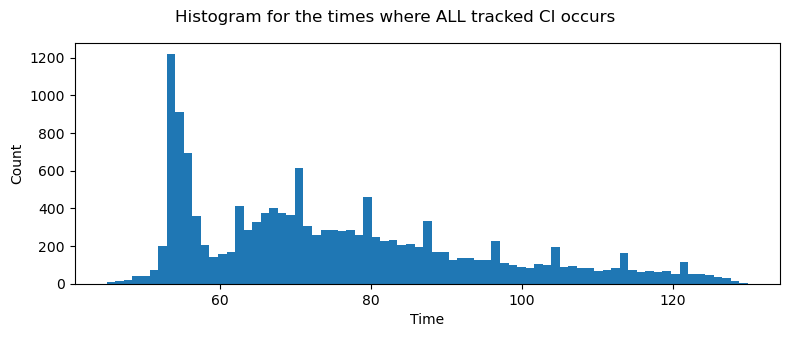

In [374]:

#MAKE SURE JOB_ARRAY HAS NOT SUBSETTED BEFORE RUNNING

if plotting==True and job_array==False:
    Ps=ALL_out_arr[:,0]
    Ts=ALL_out_arr[:,1]
    
    Time_Lst=[]
    
    kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1) #number of kms per grid
    Position=(Ts,Ps)
    for (t,p) in zip(*Position):
        Time_Lst.append(t)

if plotting==True and job_array==False:
    num_bins=100
    num_bins=75
    
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    
    fig = plt.figure(figsize=(8, 6))  # Adjust figure size for a more rectangular layout
    gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])  # 2 rows, 1 column
    
    # First subplot: Distance from SBZ Front
    ax1 = plt.subplot(gs[0])
    ax1.hist(Time_Lst, bins=num_bins)
    ax1.set_ylabel('Count')
    ax1.set_xlabel('Time')
    
    # 50*5/60 ==> 1000 LT
    # 70*5/60 ==> 1200 LT
    
    plt.suptitle('Histogram for the times where ALL tracked CI occurs')
    plt.tight_layout()  # Adjust layout to prevent overlap

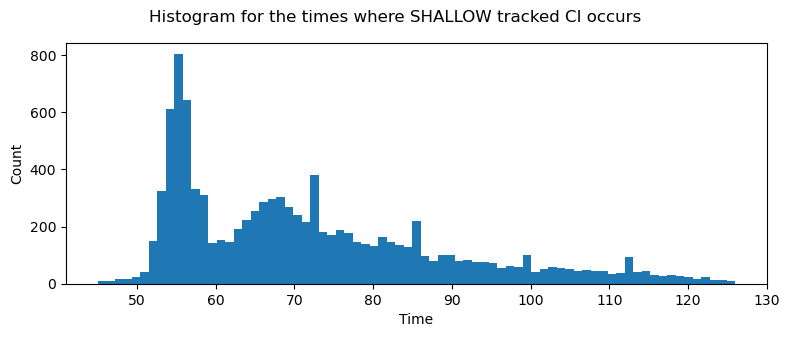

In [375]:
#MAKE SURE JOB_ARRAY HAS NOT SUBSETTED BEFORE RUNNING

if plotting==True and job_array==False:
    Ps=SHALLOW_out_arr[:,0]
    Ts=SHALLOW_out_arr[:,1]
    
    Time_Lst=[]
    
    kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1) #number of kms per grid
    Position=(Ts,Ps)
    for (t,p) in zip(*Position):
        Time_Lst.append(t)

if plotting==True and job_array==False:
    num_bins=100
    num_bins=75
    
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    
    fig = plt.figure(figsize=(8, 6))  # Adjust figure size for a more rectangular layout
    gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])  # 2 rows, 1 column
    
    # First subplot: Distance from SBZ Front
    ax1 = plt.subplot(gs[0])
    ax1.hist(Time_Lst, bins=num_bins)
    ax1.set_ylabel('Count')
    ax1.set_xlabel('Time')
    
    # 55*5/60 ==> 1030 LT
    # 70*5/60 ==> 1200 LT
    
    plt.suptitle('Histogram for the times where SHALLOW tracked CI occurs')
    plt.tight_layout()  # Adjust layout to prevent overlap

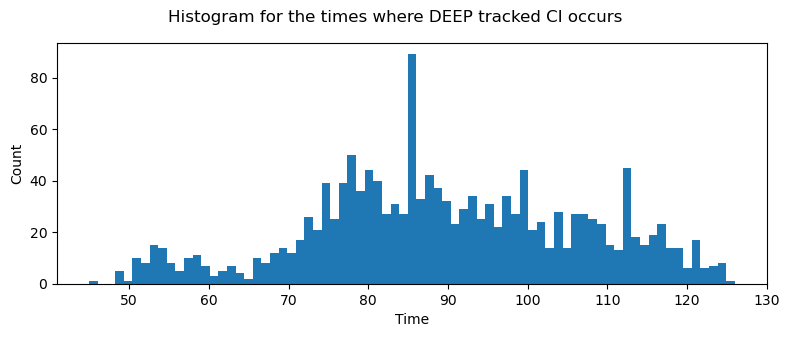

In [376]:
#MAKE SURE JOB_ARRAY HAS NOT SUBSETTED BEFORE RUNNING

if plotting==True and job_array==False:
    Ps=DEEP_out_arr[:,0]
    Ts=DEEP_out_arr[:,1]
    
    Time_Lst=[]
    
    kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1) #number of kms per grid
    Position=(Ts,Ps)
    for (t,p) in zip(*Position):
        Time_Lst.append(t)

if plotting==True and job_array==False:
    num_bins=100
    num_bins=75
    
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    
    fig = plt.figure(figsize=(8, 6))  # Adjust figure size for a more rectangular layout
    gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])  # 2 rows, 1 column
    
    # First subplot: Distance from SBZ Front
    ax1 = plt.subplot(gs[0])
    ax1.hist(Time_Lst, bins=num_bins)
    ax1.set_ylabel('Count')
    ax1.set_xlabel('Time')
    
    # 80*5/60 ==> 1230 LT
    # 90*5/60 ==> 1330 LT
    
    plt.suptitle('Histogram for the times where DEEP tracked CI occurs')
    plt.tight_layout()  # Adjust layout to prevent overlap


In [330]:
#RUNNING
##################################

In [331]:
dir2=dir+'Project_Algorithms/Lagrangian_Arrays/'
in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}_5min.h5'

########################################################################

Ps=ALL_out_arr[:,0]
Ts=ALL_out_arr[:,1]

Coast_x=int(len(data['xh'])*2/8)
Coast_Lst=[]
SBZ_Lst=[]

kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1) #number of kms per grid
Position=(Ts,Ps)

with h5py.File(in_file, 'r') as f:
    for count,(t,p) in enumerate(zip(*Position)):
        if np.mod(count,3000)==0: print(f"{count}/{len(Position[0])}")
        Coast_Dist=f['X'][t,p]-Coast_x
        Coast_Dist*=kms
        Coast_Lst.append(Coast_Dist)
        
        SBZ_Dist=f['X'][t,p]-SBZ_xmaxs[t]
        SBZ_Dist*=kms
        SBZ_Lst.append(SBZ_Dist)

# plt.hist(SBZ_Lst,bins=300)
# plt.ylabel('count');plt.xlabel('X Distance (km)')
# plt.title('Distance from SBZ Front')
# plt.xlim((-256,256))

# plt.hist(Coast_Lst,bins=300)
# plt.ylabel('count');plt.xlabel('X Distance (km)')
# plt.title('Distance from Coast')
# plt.xlim((-256,256))

0/251


In [332]:
#SAVING
dir2=dir+'Project_Algorithms/Tracked_Profiles/job_out/'
out_file=dir2+f"ALL_Tracked_Parcel_Stats_Lists_5min_{job_id}.pkl"
with open(out_file, 'wb') as f:
    pickle.dump({'SBZ_Lst': SBZ_Lst, 'Coast_Lst': Coast_Lst}, f)

In [377]:
#########################################
#RECOMBINE SEPERATE JOB_ARRAYS AFTER
recombine=False #KEEP FALSE WHEN JOBARRAY IS RUNNING
# recombine=True

In [379]:

if recombine==True:
    # SBZ_Lst=[]
    # Coast_Lst=[]
    dir2=dir+'Project_Algorithms/Tracked_Profiles/job_out/'
    
    num_jobs=60
    for job_id in range(1,num_jobs+1):
        if np.mod(job_id,10)==0: print(job_id)
        #READING BACK IN
        in_file=dir2+f"ALL_Tracked_Parcel_Stats_Lists_5min_{job_id}.pkl"
        with open(in_file, 'rb') as f:
            load_data = pickle.load(f)
            SBZ_Lst += load_data['SBZ_Lst']
            Coast_Lst += load_data['Coast_Lst']

    #SAVING
    dir3=dir+'Project_Algorithms/Tracked_Profiles/'
    out_file=dir3+f"ALL_Tracked_Parcel_Stats_Lists_5min.pkl"
    with open(out_file, 'wb') as f:
        pickle.dump({'SBZ_Lst': SBZ_Lst, 'Coast_Lst': Coast_Lst}, f)


10
20
30
40
50
60


In [380]:
#PLOTTING
###############################
plotting=False #KEEP FALSE WHEN JOB_ARRAY IS RUNNING
# plotting=True

In [381]:
if plotting==True:
    #READING BACK IN
    dir3=dir+'Project_Algorithms/Tracked_Profiles/'
    in_file=dir3+'ALL_Tracked_Parcel_Stats_Lists_5min.pkl'
    with open(in_file, 'rb') as f:
        load_data = pickle.load(f)
        SBZ_Lst = load_data['SBZ_Lst']
        Coast_Lst = load_data['Coast_Lst']

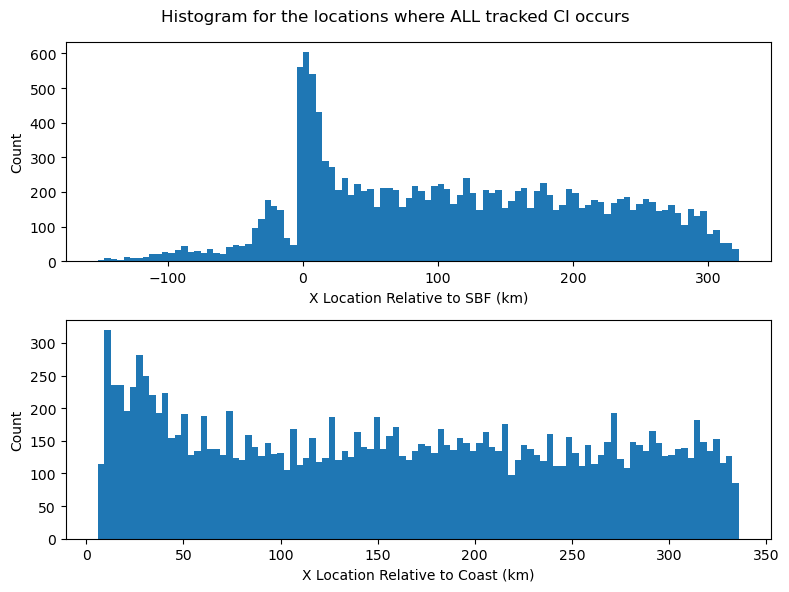

In [382]:
if plotting==True:
    num_bins=100
    # num_bins=10
    
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    
    fig = plt.figure(figsize=(8, 6))  # Adjust figure size for a more rectangular layout
    gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])  # 2 rows, 1 column
    
    # First subplot: Distance from SBZ Front
    ax1 = plt.subplot(gs[0])
    ax1.hist(SBZ_Lst, bins=num_bins)
    ax1.set_ylabel('Count')
    ax1.set_xlabel('X Location Relative to SBF (km)')
    
    # Second subplot: Distance from Coast
    ax2 = plt.subplot(gs[1])
    ax2.hist(Coast_Lst, bins=num_bins)
    ax2.set_ylabel('Count')
    ax2.set_xlabel('X Location Relative to Coast (km)')
    
    
    plt.suptitle('Histogram for the locations where ALL tracked CI occurs')
    plt.tight_layout()  # Adjust layout to prevent overlap
    


In [ ]:
#RUNNING
##############################

In [ ]:
dir2=dir+'Project_Algorithms/Lagrangian_Arrays/'
in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}_5min.h5'

####################################################################################

Ps=SHALLOW_out_arr[:,0]
Ts=SHALLOW_out_arr[:,1]

Coast_x=int(len(data['xh'])*2/8)
Coast_Lst=[]
SBZ_Lst=[]

kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1) #number of kms per grid
Position=(Ts,Ps)
with h5py.File(in_file, 'r') as f:
    for count,(t,p) in enumerate(zip(*Position)):
        if np.mod(count,3000)==0: print(f"{count}/{len(Position[0])}")
        Coast_Dist=f['X'][t,p]-Coast_x
        Coast_Dist*=kms
        Coast_Lst.append(Coast_Dist)
        
        SBZ_Dist=f['X'][t,p]-SBZ_xmaxs[t]
        SBZ_Dist*=kms
        SBZ_Lst.append(SBZ_Dist)

# plt.hist(SBZ_Lst,bins=300)
# plt.ylabel('count');plt.xlabel('X Distance (km)')
# plt.title('Distance from SBZ Front')
# plt.xlim((-256,256))

# plt.hist(Coast_Lst,bins=300)
# plt.ylabel('count');plt.xlabel('X Distance (km)')
# plt.title('Distance from Coast')
# plt.xlim((-256,256))

In [339]:
#SAVING
dir2=dir+'Project_Algorithms/Tracked_Profiles/job_out/'
out_file=dir2+f"SHALLOW_Tracked_Parcel_Stats_Lists_5min_{job_id}.pkl"
with open(out_file, 'wb') as f:
    pickle.dump({'SBZ_Lst': SBZ_Lst, 'Coast_Lst': Coast_Lst}, f)

In [340]:
#########################################
#RECOMBINE SEPERATE JOB_ARRAYS AFTER
recombine=False #KEEP FALSE WHEN JOBARRAY IS RUNNING
# recombine=True

In [384]:
if recombine==True:
    # SBZ_Lst=[]
    # Coast_Lst=[]
    dir2=dir+'Project_Algorithms/Tracked_Profiles/job_out/'
    
    num_jobs=60
    for job_id in range(1,num_jobs+1):
        if np.mod(job_id,10)==0: print(job_id)
        #READING BACK IN
        in_file=dir2+f"SHALLOW_Tracked_Parcel_Stats_Lists_5min_{job_id}.pkl"
        with open(in_file, 'rb') as f:
            load_data = pickle.load(f)
            SBZ_Lst += load_data['SBZ_Lst']
            Coast_Lst += load_data['Coast_Lst']

    #SAVING
    dir3=dir+'Project_Algorithms/Tracked_Profiles/'
    out_file=dir3+f"SHALLOW_Tracked_Parcel_Stats_Lists_5min.pkl"
    with open(out_file, 'wb') as f:
        pickle.dump({'SBZ_Lst': SBZ_Lst, 'Coast_Lst': Coast_Lst}, f)


10
20
30
40
50
60


In [342]:
#PLOTTING
###############################
plotting=False #KEEP FALSE WHEN JOB_ARRAY IS RUNNING
# plotting=True

In [385]:
if plotting==True:
    #READING BACK IN
    in_file='SHALLOW_Tracked_Parcel_Stats_Lists_5min.pkl'
    with open(in_file, 'rb') as f:
        load_data = pickle.load(f)
        SBZ_Lst = load_data['SBZ_Lst']
        Coast_Lst = load_data['Coast_Lst']

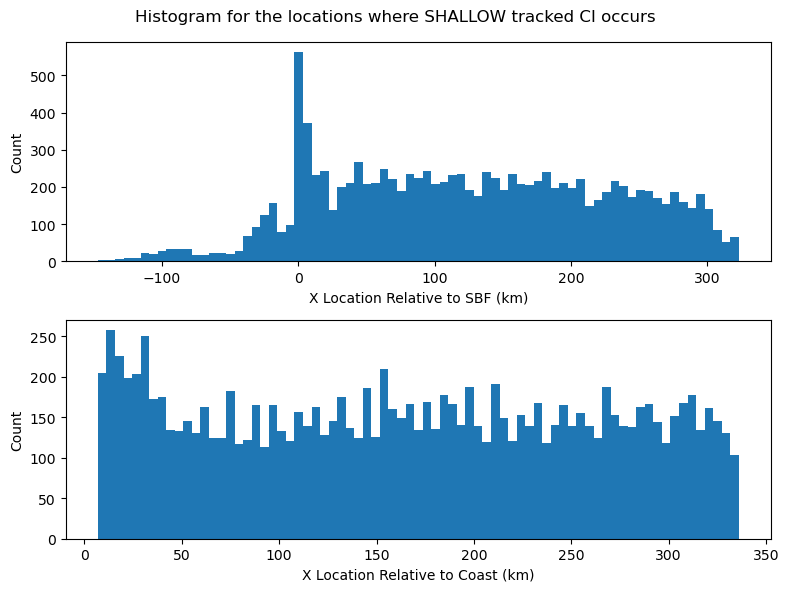

In [386]:
if plotting==True:
    num_bins=100
    num_bins=75
    
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    
    fig = plt.figure(figsize=(8, 6))  # Adjust figure size for a more rectangular layout
    gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])  # 2 rows, 1 column
    
    # First subplot: Distance from SBZ Front
    ax1 = plt.subplot(gs[0])
    ax1.hist(SBZ_Lst, bins=num_bins)
    ax1.set_ylabel('Count')
    ax1.set_xlabel('X Location Relative to SBF (km)')
    
    # Second subplot: Distance from Coast
    ax2 = plt.subplot(gs[1])
    ax2.hist(Coast_Lst, bins=num_bins)
    ax2.set_ylabel('Count')
    ax2.set_xlabel('X Location Relative to Coast (km)')
    
    
    plt.suptitle('Histogram for the locations where SHALLOW tracked CI occurs')
    plt.tight_layout()  # Adjust layout to prevent overlap
    


In [ ]:
#RUNNING
##############################

In [ ]:
dir2=dir+'Project_Algorithms/Lagrangian_Arrays/'
in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}_5min.h5'

####################################################################################

Ps=DEEP_out_arr[:,0]
Ts=DEEP_out_arr[:,1]

Coast_x=int(len(data['xh'])*2/8)
Coast_Lst=[]
SBZ_Lst=[]

kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1) #number of kms per grid
Position=(Ts,Ps)
with h5py.File(in_file, 'r') as f:
    for count,(t,p) in enumerate(zip(*Position)):
        if np.mod(count,3000)==0: print(f"{count}/{len(Position[0])}")
        Coast_Dist=f['X'][t,p]-Coast_x
        Coast_Dist*=kms
        Coast_Lst.append(Coast_Dist)
        
        SBZ_Dist=f['X'][t,p]-SBZ_xmaxs[t]
        SBZ_Dist*=kms
        SBZ_Lst.append(SBZ_Dist)

# plt.hist(SBZ_Lst,bins=300)
# plt.ylabel('count');plt.xlabel('X Distance (km)')
# plt.title('Distance from SBZ Front')
# plt.xlim((-256,256))

# plt.hist(Coast_Lst,bins=300)
# plt.ylabel('count');plt.xlabel('X Distance (km)')
# plt.title('Distance from Coast')
# plt.xlim((-256,256))

In [347]:
#SAVING
dir2=dir+'Project_Algorithms/Tracked_Profiles/job_out/'
out_file=dir2+f"DEEP_Tracked_Parcel_Stats_Lists_5min_{job_id}.pkl"
with open(out_file, 'wb') as f:
    pickle.dump({'SBZ_Lst': SBZ_Lst, 'Coast_Lst': Coast_Lst}, f)

In [348]:
#########################################
#RECOMBINE SEPERATE JOB_ARRAYS AFTER
recombine=False #KEEP FALSE WHEN JOBARRAY IS RUNNING
# recombine=True

In [421]:
if recombine==True:
    # SBZ_Lst=[]
    # Coast_Lst=[]
    dir2=dir+'Project_Algorithms/Tracked_Profiles/job_out/'
    
    num_jobs=60
    for job_id in range(1,num_jobs+1):
        if np.mod(job_id,10)==0: print(job_id)
        #READING BACK IN
        in_file=dir2+f"DEEP_Tracked_Parcel_Stats_Lists_5min_{job_id}.pkl"
        with open(in_file, 'rb') as f:
            load_data = pickle.load(f)
            SBZ_Lst += load_data['SBZ_Lst']
            Coast_Lst += load_data['Coast_Lst']

    #SAVING
    dir3=dir+'Project_Algorithms/Tracked_Profiles/'
    out_file=dir3+f"DEEP_Tracked_Parcel_Stats_Lists_5min.pkl"
    with open(out_file, 'wb') as f:
        pickle.dump({'SBZ_Lst': SBZ_Lst, 'Coast_Lst': Coast_Lst}, f)


10
20
30
40
50
60


In [425]:
#PLOTTING
###############################
plotting=False #KEEP FALSE WHEN JOB_ARRAY IS RUNNING
# plotting=True

In [428]:
dir3=dir+'Project_Algorithms/Tracked_Profiles/'
if plotting==True:
    #READING BACK IN
    in_file=dir3+f"DEEP_Tracked_Parcel_Stats_Lists_5min.pkl"
    with open(in_file, 'rb') as f:
        load_data = pickle.load(f)
        SBZ_Lst = load_data['SBZ_Lst']
        Coast_Lst = load_data['Coast_Lst']

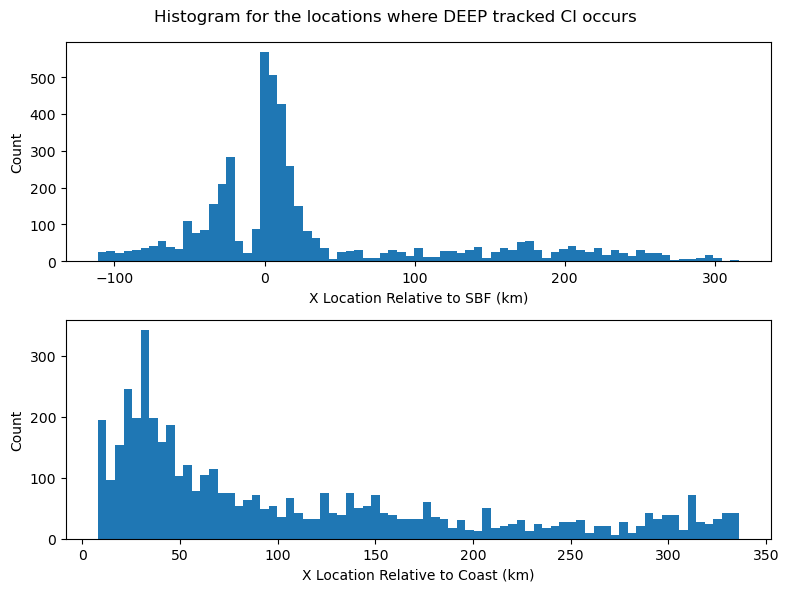

In [429]:
if plotting==True:
    num_bins=100
    num_bins=75
    
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    
    fig = plt.figure(figsize=(8, 6))  # Adjust figure size for a more rectangular layout
    gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])  # 2 rows, 1 column
    
    # First subplot: Distance from SBZ Front
    ax1 = plt.subplot(gs[0])
    ax1.hist(SBZ_Lst, bins=num_bins)
    ax1.set_ylabel('Count')
    ax1.set_xlabel('X Location Relative to SBF (km)')
    
    # Second subplot: Distance from Coast
    ax2 = plt.subplot(gs[1])
    ax2.hist(Coast_Lst, bins=num_bins)
    ax2.set_ylabel('Count')
    ax2.set_xlabel('X Location Relative to Coast (km)')
    
    
    plt.suptitle('Histogram for the locations where DEEP tracked CI occurs')
    plt.tight_layout()  # Adjust layout to prevent overlap
    


In [353]:
#RUNNING
####################################################
#WHEN TRACKED PARCELS EXIT CLOUDY REGION

In [354]:
dir2=dir+'Project_Algorithms/Lagrangian_Arrays/'
in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}_5min.h5'

####################################################################################

#FIND WHERE PARCEL LEAVES UPDRAFT (FOR ALL AND DEEP PARCELS)
def find_after_time(out_arr):
    wthresh=0.5;qcqithresh=1e-6
    
    after_array=np.zeros(len(out_arr),dtype=int)


    with h5py.File(in_file, 'r') as f:
        for count,out_row in enumerate(out_arr): 
            if np.mod(count,3000)==0: print(f'{count}/{len(out_arr)}')
            
            p=out_row[0]
            t2=out_row[2]
            
            wthresh=0.5;qcqithresh=1e-6
            after=np.where((f['W'][t2:,p]<wthresh)|(f['QCQI'][t2:,p]<qcqithresh))
            if len(after[0])!=0:
                after_array[count]=after[0][0]
    return after_array

ALL_out_after_array=find_after_time(ALL_out_arr)
SHALLOW_out_after_array=np.zeros(len(SHALLOW_out_arr),dtype=int)
DEEP_out_after_array=find_after_time(DEEP_out_arr)

# ALL_save_after_array=find_after_time(ALL_save_arr)
# SHALLOW_save_after_array=np.zeros(len(SHALLOW_save_arr),dtype=int)
# DEEP_save_after_array=find_after_time(DEEP_save_arr)

0/251
0/27


In [355]:
#AFTER TIME NEEDS TO BE ADDED TO FINAL TIMESTEPS IN OUT_ARR
ALL_out_after_array+=(ALL_out_arr[:,2]+1-ALL_out_arr[:,1]).astype(int)
SHALLOW_out_after_array+=(SHALLOW_out_arr[:,2]+1-SHALLOW_out_arr[:,1]).astype(int)
DEEP_out_after_array+=(DEEP_out_arr[:,2]+1-DEEP_out_arr[:,1]).astype(int)

In [356]:
#SAVING
dir2=dir+'Project_Algorithms/Tracked_Profiles/job_out/'
out_file=dir2+f"After_Arrays_5min_{job_id}.npz"
np.savez(out_file,
         ALL=ALL_out_after_array,
         SHALLOW=SHALLOW_out_after_array,
         DEEP=DEEP_out_after_array)

In [357]:
#########################################
#RECOMBINE SEPERATE JOB_ARRAYS AFTER
recombine=False #KEEP FALSE WHEN JOBARRAY IS RUNNING
# recombine=True

In [394]:
if recombine == True:
    dir2 = dir + 'Project_Algorithms/Tracked_Profiles/job_out/'
    
    # Initialize empty lists to collect arrays
    ALL_list = []
    SHALLOW_list = []
    DEEP_list = []

    num_jobs = 60
    for job_id in range(1, num_jobs + 1):
        if np.mod(job_id, 10) == 0: print(f"Loading job {job_id}")

        in_file = dir2 + f"After_Arrays_5min_{job_id}.npz"
        with np.load(in_file) as data:
            ALL_list.append(data['ALL'])
            SHALLOW_list.append(data['SHALLOW'])
            DEEP_list.append(data['DEEP'])

    # Concatenate all arrays
    ALL_combined = np.concatenate(ALL_list, axis=0)
    SHALLOW_combined = np.concatenate(SHALLOW_list, axis=0)
    DEEP_combined = np.concatenate(DEEP_list, axis=0)

    # Save to single .npz file
    dir3 = dir + 'Project_Algorithms/Tracked_Profiles/'
    out_file = dir3 + "After_Arrays_5min.npz"
    np.savez(out_file,
             ALL=ALL_combined,
             SHALLOW=SHALLOW_combined,
             DEEP=DEEP_combined)

    # print(f"Saved combined arrays to: {out_file}")


Loading job 10
Loading job 20
Loading job 30
Loading job 40
Loading job 50
Loading job 60


In [359]:
#PLOTTING
###############################
plotting=False #KEEP FALSE WHEN JOB_ARRAY IS RUNNING
# plotting=True

In [395]:
if plotting==True:
    in_file='After_Arrays_5min.npz'
    load_data = np.load(in_file)
    ALL_out_after_array = load_data['ALL']
    SHALLOW_out_after_array = load_data['SHALLOW']
    DEEP_out_after_array = load_data['DEEP']

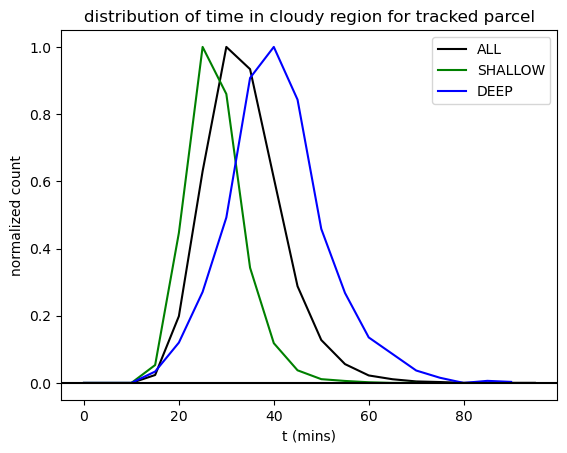

In [396]:
if plotting==True:
    def get_dist(array):
        max_ind=np.max(array)+1
        profile=np.zeros((max_ind,2));profile[:,1]=np.arange(max_ind)
        
        for t in np.arange(max_ind):
            profile[t,0]+=len(array[array==t])
        return profile
    
    arrays=[ALL_out_after_array,SHALLOW_out_after_array,DEEP_out_after_array]
    labels=['ALL','SHALLOW','DEEP']
    colors=['black','green','blue']
    
    
    ALL_profile=get_dist(arrays[0])
    SHALLOW_profile=get_dist(arrays[1])
    DEEP_profile=get_dist(arrays[2])
    
    profiles=[ALL_profile,SHALLOW_profile,DEEP_profile]
    
    
    for (profile,label,color) in zip(profiles,labels,colors):
        profile[:, 0] /= np.max(profile[:, 0])
        plt.plot(profile[:,1]*5,profile[:,0],label=label,color=color)
        plt.ylabel('normalized count');plt.xlabel('t (mins)')
        plt.title('distribution of time in cloudy region for tracked parcel')
    plt.legend()
    plt.axhline(0,color='black')